# Ovrlpy applied to vizgen receptor data map



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

import ovrlpy

In [2]:
n_slice = 2

coordinate_path = "./detected_transcripts.parquet"
signature_file = (
    "/dh-projects/ag-ishaque/raw_data/Xenium-benchmark/scRNAseq/trimmed_means.csv"
)

In [3]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True, parents=True)

In [4]:
coordinate_df = ovrlpy.io.read_MERSCOPE(coordinate_path, additional_columns=["cell_id"])

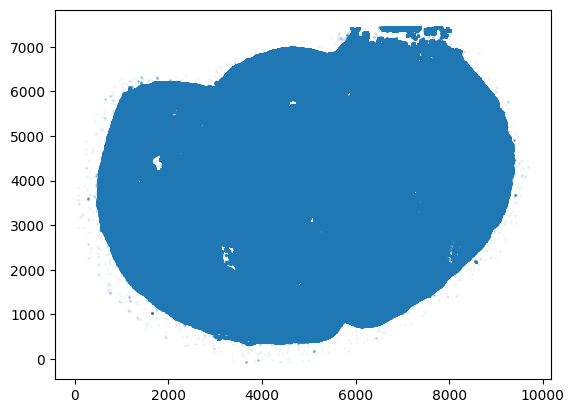

In [5]:
_ = plt.scatter(coordinate_df["x"], coordinate_df["y"], s=1, alpha=0.05)

In [6]:
brain = ovrlpy.Ovrlp(coordinate_df, n_components=30, n_workers=16, random_state=42)
brain.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 50370 pseudocells
sampling expression:


100%|██████████| 56/56 [00:55<00:00,  1.01it/s]


Modeling 30 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 320/320 [06:46<00:00,  1.27s/it]


In [7]:
signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [8]:
signatures = pd.read_csv(signature_file, index_col=0).T.loc[
    :, lambda df: df.columns.isin(brain.genes)
]

signatures = signatures.groupby(
    lambda x: x.split("_")[1].split(" ")[0].split("-")[0]
).mean()

signatures.index = signatures.index.str.replace("/", "-")
signatures.index.name = "celltype"
signatures.columns.name = "gene"

In [9]:
brain.fit_signatures(signatures)

In [10]:
import pickle

with open("merscope_brain.pickle", "wb") as file:
    pickle.dump(brain, file)

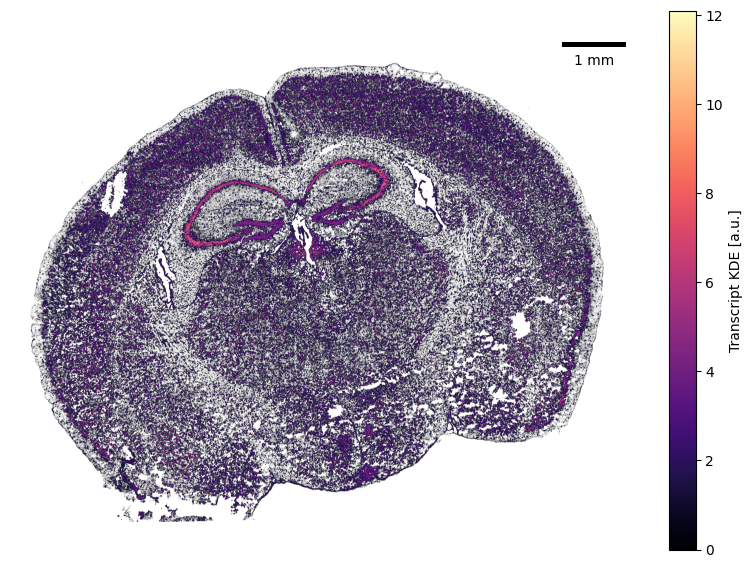

In [11]:
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

im = ax.imshow(signal_strength, cmap="magma", alpha=(signal_strength.clip(0, 1)))
ax.axis("off")
ax.invert_xaxis()
ax.add_artist(ScaleBar(1, units="um"))

fig.colorbar(im, label="Transcript KDE [a.u.]")

fig.savefig(out_dir / "signal_strength.svg", dpi=600)

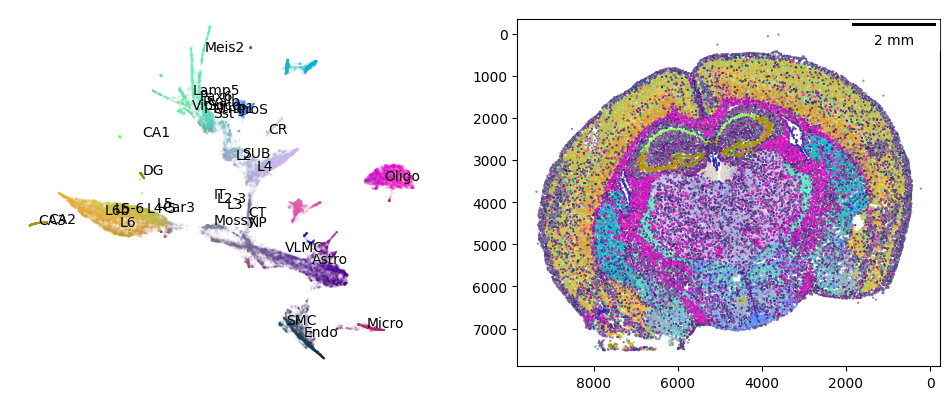

In [12]:
fig = ovrlpy.plot_pseudocells(brain)

fig.axes[1].invert_yaxis()
fig.axes[1].invert_xaxis()

fig.savefig(out_dir / "receptor-fit.svg", dpi=600)

In [13]:
doublet_df = brain.detect_doublets(min_signal=3, integrity_sigma=2)

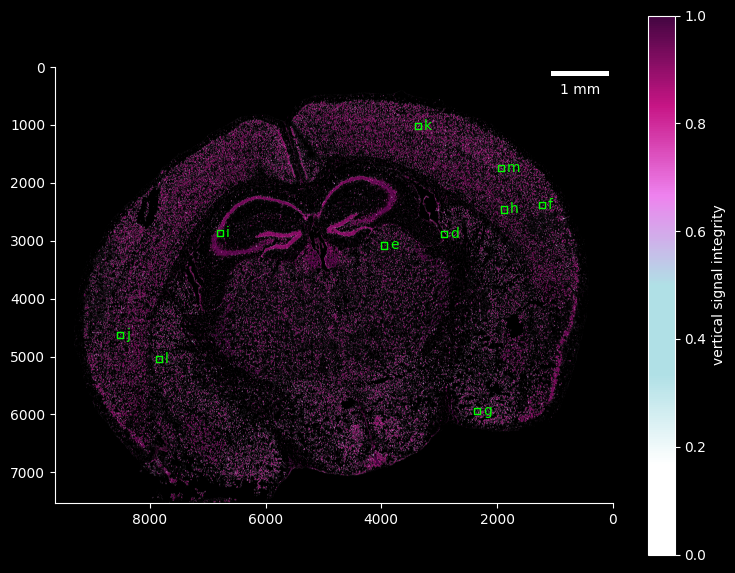

In [14]:
fig = ovrlpy.plot_signal_integrity(
    brain,
    signal_threshold=3,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "box_alpha": 0, "color": "w"},
    figsize=(9, 7),
)

fig.axes[0].invert_yaxis()
fig.axes[0].invert_xaxis()


alphabet = "abcdefghijklmnopqrstuvwxyz"

for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    fig.axes[0].text(
        x - 100, y, alphabet[i + 3], fontsize=10, color="lime", va="center"
    )

    fig.axes[0].scatter(
        x, y, marker="s", s=20, edgecolors="lime", facecolors="None", lw=1
    )


fig.savefig(out_dir / "receptor_integrity.svg", dpi=600)

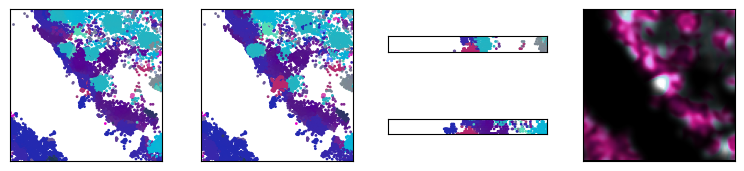

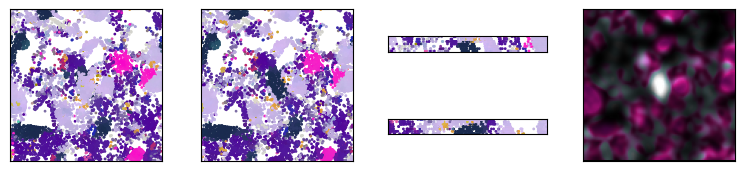

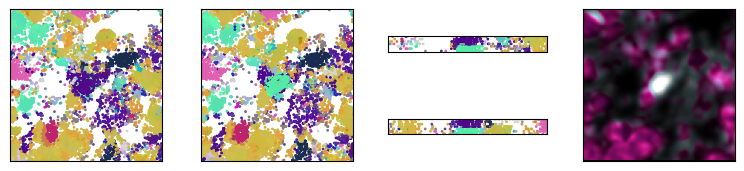

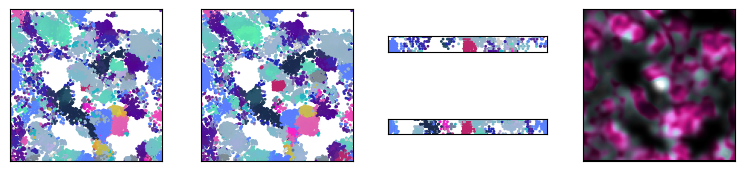

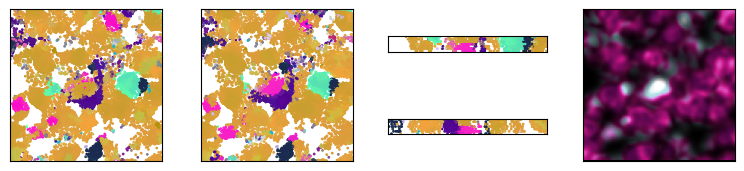

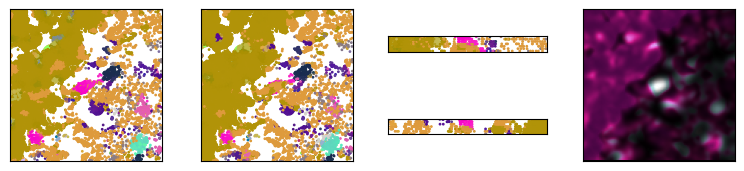

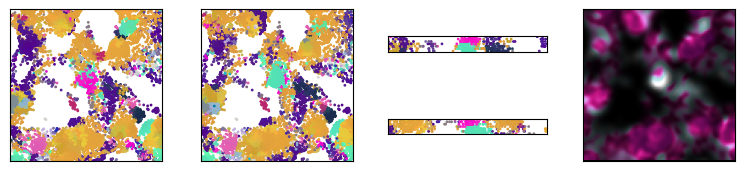

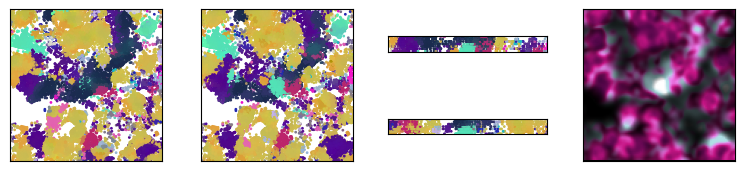

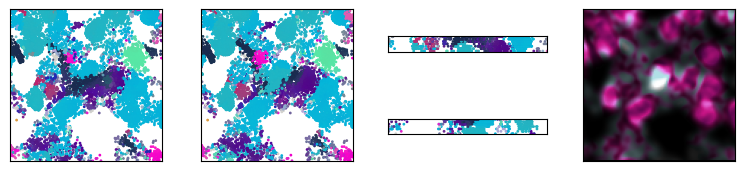

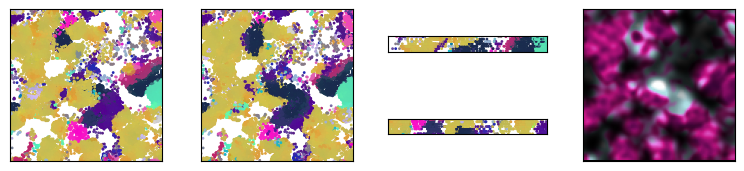

In [15]:
import sys

sys.path.append("..")

from utils import plot_doublet

doublet_dir = out_dir / "doublet-case-visualizations"
doublet_dir.mkdir(exist_ok=True, parents=True)


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    fig = plot_doublet(brain, x, y)
    fig.savefig(doublet_dir / f"receptor_doublet_case_{i+1}.svg", dpi=600)